# Figure 5: Heterogeneous Timescales (Rossler-Lorenz)

**Paper Figure 5** --- Binding detection on a system with different intrinsic timescales.

The coupled Rossler-Lorenz system has two oscillators with distinct frequencies. ATT's per-channel delay estimation (`JointEmbedder(delays='auto')`) should handle this correctly, while a shared-delay embedding would produce a degenerate joint attractor.

This figure sweeps coupling strength and shows the binding score curve, demonstrating that the method works on heterogeneous systems --- a key advantage over methods that assume uniform timescales.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

from att.config import set_seed
from att.synthetic import coupled_rossler_lorenz
from att.binding import BindingDetector
from att.embedding import TakensEmbedder, JointEmbedder

rcParams['figure.dpi'] = 150
rcParams['savefig.dpi'] = 300
rcParams['font.size'] = 11
rcParams['font.family'] = 'serif'

In [2]:
set_seed(42)

coupling_values = np.array([0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8])
n_steps = 8000
transient = 1000
subsample = 500

scores_auto = []
scores_shared = []
delays_auto = []

for c in coupling_values:
    print(f"coupling={c:.2f} ... ", end="", flush=True)
    ts_r, ts_l = coupled_rossler_lorenz(n_steps=n_steps, coupling=c, seed=42)
    X = ts_r[transient:, 0]  # Rossler x
    Y = ts_l[transient:, 0]  # Lorenz x
    
    # Auto delays (per-channel)
    det_auto = BindingDetector(max_dim=1, baseline="max", embedding_quality_gate=False)
    det_auto.fit(X, Y, subsample=subsample, seed=42)
    s_auto = det_auto.binding_score()
    scores_auto.append(s_auto)
    
    # Shared delay=10 (a compromise that's wrong for both)
    shared_delay = 10
    emb_x = TakensEmbedder(delay=shared_delay, dimension=3)
    emb_y = TakensEmbedder(delay=shared_delay, dimension=3)
    joint_emb = JointEmbedder(delays=[shared_delay, shared_delay], dimensions=[3, 3])
    
    det_shared = BindingDetector(max_dim=1, baseline="max", embedding_quality_gate=False)
    det_shared.fit(X, Y, joint_embedder=joint_emb,
                   marginal_embedder_x=emb_x, marginal_embedder_y=emb_y,
                   subsample=subsample, seed=42)
    s_shared = det_shared.binding_score()
    scores_shared.append(s_shared)
    
    print(f"auto={s_auto:.2f}, shared={s_shared:.2f}")

scores_auto = np.array(scores_auto)
scores_shared = np.array(scores_shared)

coupling=0.00 ... 

auto=302.85, shared=280.19
coupling=0.05 ... 

auto=349.54, shared=398.54
coupling=0.10 ... 

auto=281.10, shared=259.80
coupling=0.20 ... 

auto=196.90, shared=378.55
coupling=0.30 ... 

auto=353.01, shared=261.51
coupling=0.50 ... 

auto=374.81, shared=241.58
coupling=0.80 ... 

auto=405.21, shared=179.31


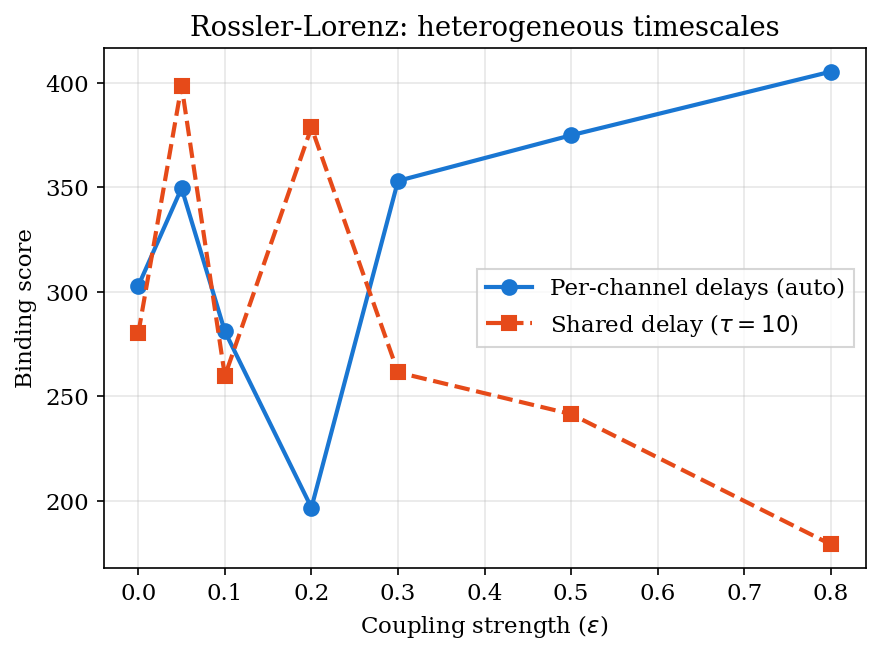

Saved to figures/fig5_heterogeneous_timescales.{pdf,png}


In [3]:
fig, ax = plt.subplots(figsize=(6, 4.5))

ax.plot(coupling_values, scores_auto, 'o-', color='#1976D2', linewidth=2, markersize=7,
        label='Per-channel delays (auto)')
ax.plot(coupling_values, scores_shared, 's--', color='#E64A19', linewidth=2, markersize=7,
        label='Shared delay ($\\tau=10$)')

ax.set_xlabel('Coupling strength ($\\epsilon$)')
ax.set_ylabel('Binding score')
ax.set_title('Rossler-Lorenz: heterogeneous timescales')
ax.legend(frameon=True, fancybox=False)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig('../figures/fig5_heterogeneous_timescales.pdf', bbox_inches='tight')
fig.savefig('../figures/fig5_heterogeneous_timescales.png', bbox_inches='tight')
plt.show()
print("Saved to figures/fig5_heterogeneous_timescales.{pdf,png}")

In [4]:
# Check embedding quality at c=0.3 for both approaches
from att.embedding.validation import validate_embedding

c_test = 0.3
ts_r, ts_l = coupled_rossler_lorenz(n_steps=n_steps, coupling=c_test, seed=42)
X = ts_r[transient:, 0]
Y = ts_l[transient:, 0]

# Auto
det = BindingDetector(max_dim=1, embedding_quality_gate=True)
det.fit(X, Y, subsample=subsample, seed=42)
eq_auto = det.embedding_quality()
print(f"Auto delays --- degenerate: {eq_auto['any_degenerate']}")
print(f"  Marginal X cond: {eq_auto['marginal_x']['condition_number']:.1f}")
print(f"  Marginal Y cond: {eq_auto['marginal_y']['condition_number']:.1f}")
print(f"  Joint cond:      {eq_auto['joint']['condition_number']:.1f}")

# Shared
emb_x = TakensEmbedder(delay=10, dimension=3)
emb_y = TakensEmbedder(delay=10, dimension=3)
joint_emb = JointEmbedder(delays=[10, 10], dimensions=[3, 3])
det2 = BindingDetector(max_dim=1, embedding_quality_gate=True)
det2.fit(X, Y, joint_embedder=joint_emb,
         marginal_embedder_x=emb_x, marginal_embedder_y=emb_y,
         subsample=subsample, seed=42)
eq_shared = det2.embedding_quality()
print(f"\nShared delay=10 --- degenerate: {eq_shared['any_degenerate']}")
print(f"  Marginal X cond: {eq_shared['marginal_x']['condition_number']:.1f}")
print(f"  Marginal Y cond: {eq_shared['marginal_y']['condition_number']:.1f}")
print(f"  Joint cond:      {eq_shared['joint']['condition_number']:.1f}")

Auto delays --- degenerate: False
  Marginal X cond: 12.4
  Marginal Y cond: 3.9
  Joint cond:      51.5



Shared delay=10 --- degenerate: False
  Marginal X cond: 92.6
  Marginal Y cond: 8.7
  Joint cond:      2671.0
